In [10]:
from sklearn.datasets import load_diabetes
diabetes = load_diabetes(as_frame=True)

X, y = diabetes.data, diabetes.target
diabetes


{'data':           age       sex       bmi        bp        s1        s2        s3  \
 0    0.038076  0.050680  0.061696  0.021872 -0.044223 -0.034821 -0.043401   
 1   -0.001882 -0.044642 -0.051474 -0.026328 -0.008449 -0.019163  0.074412   
 2    0.085299  0.050680  0.044451 -0.005670 -0.045599 -0.034194 -0.032356   
 3   -0.089063 -0.044642 -0.011595 -0.036656  0.012191  0.024991 -0.036038   
 4    0.005383 -0.044642 -0.036385  0.021872  0.003935  0.015596  0.008142   
 ..        ...       ...       ...       ...       ...       ...       ...   
 437  0.041708  0.050680  0.019662  0.059744 -0.005697 -0.002566 -0.028674   
 438 -0.005515  0.050680 -0.015906 -0.067642  0.049341  0.079165 -0.028674   
 439  0.041708  0.050680 -0.015906  0.017293 -0.037344 -0.013840 -0.024993   
 440 -0.045472 -0.044642  0.039062  0.001215  0.016318  0.015283 -0.028674   
 441 -0.045472 -0.044642 -0.073030 -0.081413  0.083740  0.027809  0.173816   
 
            s4        s5        s6  
 0   -0.002592  0

In [11]:
diabetes.feature_names        # list of features
print(diabetes.DESCR)         # full description + notes
diabetes.frame.head()         # first rows (as_frame=True)
diabetes.data.isna().sum()    # missing-value check

.. _diabetes_dataset:

Diabetes dataset
----------------

Ten baseline variables, age, sex, body mass index, average blood
pressure, and six blood serum measurements were obtained for each of n =
442 diabetes patients, as well as the response of interest, a
quantitative measure of disease progression one year after baseline.

**Data Set Characteristics:**

:Number of Instances: 442

:Number of Attributes: First 10 columns are numeric predictive values

:Target: Column 11 is a quantitative measure of disease progression one year after baseline

:Attribute Information:
    - age     age in years
    - sex
    - bmi     body mass index
    - bp      average blood pressure
    - s1      tc, total serum cholesterol
    - s2      ldl, low-density lipoproteins
    - s3      hdl, high-density lipoproteins
    - s4      tch, total cholesterol / HDL
    - s5      ltg, possibly log of serum triglycerides level
    - s6      glu, blood sugar level

Note: Each of these 10 feature variables have bee

age    0
sex    0
bmi    0
bp     0
s1     0
s2     0
s3     0
s4     0
s5     0
s6     0
dtype: int64

In [12]:
from sklearn.model_selection import train_test_split
X_train , X_test , y_train , y_test = train_test_split(X , y , test_size=0.2 , random_state=42)

In [13]:
X_train

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6
17,0.070769,0.050680,0.012117,0.056301,0.034206,0.049416,-0.039719,0.034309,0.027364,-0.001078
66,-0.009147,0.050680,-0.018062,-0.033213,-0.020832,0.012152,-0.072854,0.071210,0.000272,0.019633
137,0.005383,-0.044642,0.049840,0.097615,-0.015328,-0.016345,-0.006584,-0.002592,0.017036,-0.013504
245,-0.027310,-0.044642,-0.035307,-0.029770,-0.056607,-0.058620,0.030232,-0.039493,-0.049872,-0.129483
31,-0.023677,-0.044642,-0.065486,-0.081413,-0.038720,-0.053610,0.059685,-0.076395,-0.037129,-0.042499
...,...,...,...,...,...,...,...,...,...,...
106,-0.096328,-0.044642,-0.076264,-0.043542,-0.045599,-0.034821,0.008142,-0.039493,-0.059471,-0.083920
270,0.005383,0.050680,0.030440,0.083844,-0.037344,-0.047347,0.015505,-0.039493,0.008641,0.015491
348,0.030811,-0.044642,-0.020218,-0.005670,-0.004321,-0.029497,0.078093,-0.039493,-0.010903,-0.001078
435,-0.012780,-0.044642,-0.023451,-0.040099,-0.016704,0.004636,-0.017629,-0.002592,-0.038460,-0.038357


In [14]:
y_train

17     144.0
66     150.0
137    280.0
245    125.0
31      59.0
       ...  
106    134.0
270    202.0
348    148.0
435     64.0
102    302.0
Name: target, Length: 353, dtype: float64

In [21]:
X_train_mat = X_train.to_numpy()
y_train_vec = y_train.to_numpy()
y_train_vec = y_train_vec.reshape(-1 , 1)
print(X_train_mat.shape , y_train_vec.shape)

(353, 10) (353, 1)


In [22]:
X_test_mat = X_test.to_numpy()
y_test_vec = y_test.to_numpy()
y_test_vec = y_test_vec.reshape(-1 , 1)
print(X_test_mat.shape , y_test_vec.shape)

(89, 10) (89, 1)


In [37]:
import numpy as np
lr = 0.01
epochs = 500
w = np.zeros((X_train.shape[1] , 1))
b = 0
losses = []

In [38]:
def forward(X , y , w , b):
    m = X.shape[0]
    y_hat = X @ w + b
    loss = np.mean((y_hat - y) ** 2)
    return y_hat , loss

In [39]:
def backward(X, y , y_hat , w , b):
    m = X.shape[0]
    dw = (2/m) * X.T @ (y_hat - y)
    db = (2/m) * np.sum(y_hat - y)
    w = w - (lr * dw)
    b = b - (lr * db)
    return w , b


In [40]:
for i in range(epochs):
    y_hat , loss = forward(X_train_mat , y_train_vec , w , b)
    losses.append(loss)
    w , b = backward(X_train_mat , y_train_vec , y_hat , w , b)


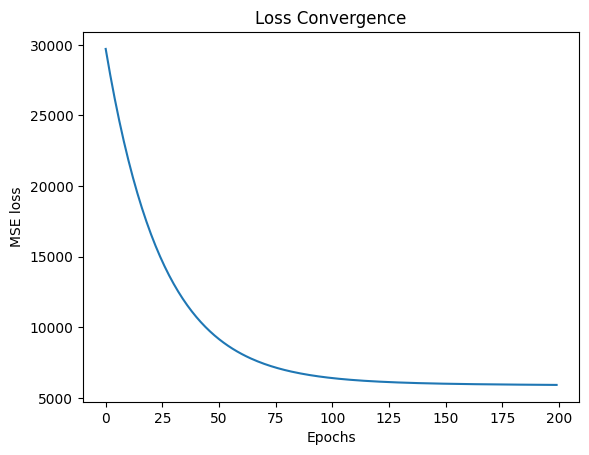

In [41]:
import matplotlib.pyplot as plt
plt.plot(losses)
plt.xlabel("Epochs")
plt.ylabel("MSE loss")
plt.title("Loss Convergence")
plt.show()

In [42]:
y_pred , test_loss = forward(X_test_mat , y_test_vec , w , b)

In [71]:
y_true = y_test_vec.flatten()
y_pred = y_pred.flatten()
error = y_pred - y_true
abs_error = np.abs(error)
import pandas as pd

results_df = pd.DataFrame({
    "True value": y_true,
    "Predicted value": y_pred,
    "Error (Pred - True)": error,
    "Absolute Error": abs_error
})

results_df.head(50)


,True value,Predicted value,Error (Pred - True),Absolute Error
0,219.0,155.848045,-63.151955,63.151955
1,70.0,153.792690,83.792690,83.792690
2,202.0,155.344116,-46.655884,46.655884
3,230.0,163.306342,-66.693658,66.693658
4,111.0,154.129932,43.129932,43.129932
5,84.0,152.528533,68.528533,68.528533
6,242.0,159.843464,-82.156536,82.156536
7,272.0,158.873645,-113.126355,113.126355
8,94.0,150.309777,56.309777,56.309777
9,96.0,152.780930,56.780930,56.780930


In [72]:
new_sgd_w = np.zeros(X_train_mat.shape[1])   # 1D weights
new_sgd_b = 0.0
losses_sgd = []
lr_sgd = 0.01
n_samples = X_train_mat.shape[0]

for epoch in range(epochs):
    indices = np.random.permutation(n_samples)
    epoch_losses = []
    for ind in indices:
        x_i = X_train_mat[ind]                # (n_features,)
        y_i = float(y_train_vec[ind].item())  # scalar
        y_hat = x_i.dot(new_sgd_w) + new_sgd_b
        err = y_hat - y_i
        epoch_losses.append(err**2)           # squared error
        dw = 2 * err * x_i                    # (n_features,)
        db = 2 * err
        new_sgd_w -= lr_sgd * dw
        new_sgd_b -= lr_sgd * db
    losses_sgd.append(np.mean(epoch_losses))  # per-epoch MSE

In [73]:
def plot(losses):
    import matplotlib.pyplot as plt
    plt.plot(losses)
    plt.xlabel("Epochs")
    plt.ylabel("MSE loss")
    plt.title("Loss Convergence")
    plt.show()

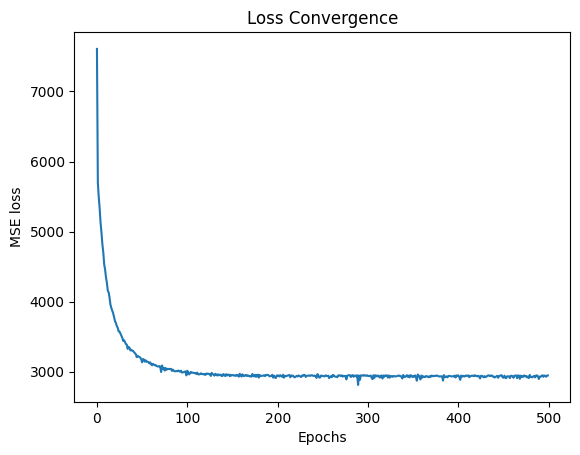

In [74]:
plot(losses_sgd)

In [ ]:
new_sgd_w = np.zeros(X_train_mat.shape[1])   # 1D weights
new_sgd_b = 0.0
losses_sgd = []
lr_sgd = 0.01
n_samples = X_train_mat.shape[0]

for epoch in range(epochs):
    indices = np.random.permutation(n_samples)
    epoch_losses = []
    for ind in indices:
        x_i = X_train_mat[ind]                # (n_features,)
        y_i = float(y_train_vec[ind].item())  # scalar
        y_hat = x_i.dot(new_sgd_w) + new_sgd_b
        err = y_hat - y_i
        epoch_losses.append(err**2)           # squared error
        dw = 2 * err * x_i                    # (n_features,)
        db = 2 * err
        new_sgd_w -= lr_sgd * dw
        new_sgd_b -= lr_sgd * db
    losses_sgd.append(np.mean(epoch_losses))  # per-epoch MSE

In [ ]:
# Momentum SGD (variables renamed to momentum_w / momentum_b)
momentum_w = np.zeros(X_train_mat.shape[1])
momentum_b = 0.0
v_w = np.zeros_like(momentum_w)
v_b = 0.0
losses_momentum = []
lr_m = 0.01
beta = 0.9
n_samples = X_train_mat.shape[0]

for epoch in range(epochs):
    perm = np.random.permutation(n_samples)
    epoch_losses = []
    for ind in perm:
        x_i = X_train_mat[ind]                    # (n_features,)
        y_i = float(y_train_vec[ind].item())      # scalar
        y_hat = x_i.dot(momentum_w) + momentum_b
        err = y_hat - y_i
        epoch_losses.append(err**2)
        dw = 2 * err * x_i
        db = 2 * err
        # classical momentum update
        v_w = beta * v_w + lr_m * dw
        v_b = beta * v_b + lr_m * db
        momentum_w -= v_w
        momentum_b -= v_b
    losses_momentum.append(np.mean(epoch_losses))

# Diagnostics
print("Final momentum bias:", momentum_b)
print("Final momentum weight norm:", np.linalg.norm(momentum_w))
print("Final train MSE (last epoch):", losses_momentum[-1])

# Plot training curve
import matplotlib.pyplot as plt
plt.plot(losses_momentum, label='Momentum SGD')
plt.xlabel('Epochs')
plt.ylabel('MSE')
plt.title('Momentum SGD Training Curve')
plt.legend()
plt.show()
